In [ ]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    r2_score
)

In [4]:
X_combined = np.load("X_combined.npy")

# Load targets
y_pIC50 = np.load("y_pIC50.npy")

y_active = np.load("y_active.npy")

# Load descriptor names
desc_columns = np.load("desc_columns.npy", allow_pickle=True)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Regression split
X_train, X_test, y_train, y_test = train_test_split(
    X_combined,
    y_pIC50,
    test_size=0.2,
    random_state=42
)

# Classification split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_combined,
    y_active,
    test_size=0.2,
    random_state=42,
    stratify=y_active
)

# Scaling
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

X_train_csc = scaler.fit_transform(X_train_c)
X_test_csc = scaler.transform(X_test_c)

Random Forest → Accuracy: 0.918 | AUC-ROC: 0.964

Top 20 most important features:
Morgan_bit_708    0.059127
Morgan_bit_489    0.042384
Morgan_bit_343    0.040788
Morgan_bit_491    0.039639
Morgan_bit_794    0.030474
Morgan_bit_888    0.030272
Morgan_bit_786    0.026342
Morgan_bit_329    0.025534
Morgan_bit_607    0.024631
Morgan_bit_428    0.021367
Morgan_bit_202    0.019311
Morgan_bit_378    0.018761
Morgan_bit_128    0.017507
Morgan_bit_766    0.017160
Morgan_bit_728    0.015552
Morgan_bit_703    0.014841
MW                0.014713
Morgan_bit_636    0.014141
Morgan_bit_133    0.013858
Morgan_bit_909    0.013536
dtype: float64
RF Regressor → R²: 0.630


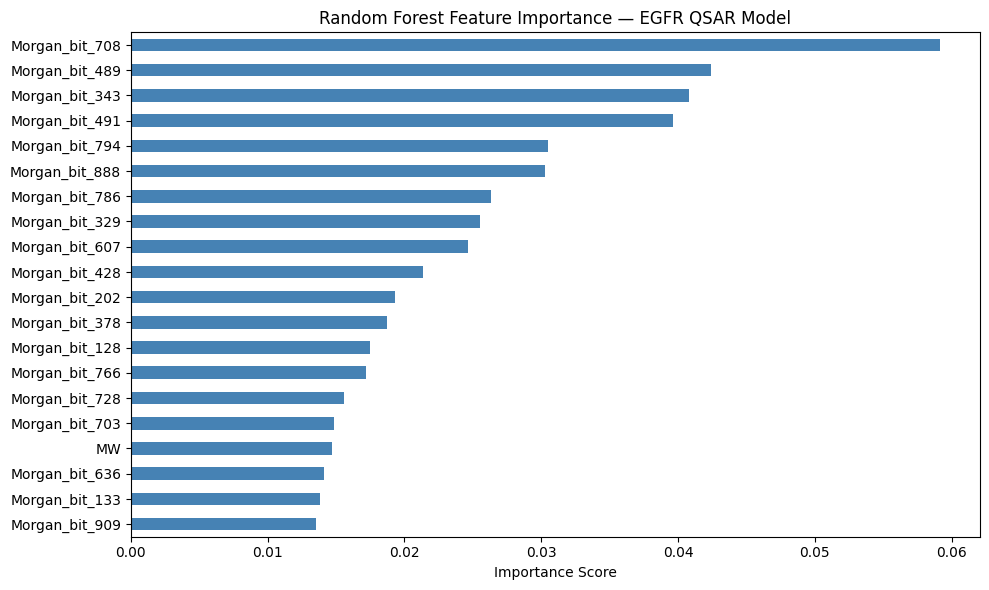

In [8]:
import os
# ─── RF Classifier ────────────────────────────────────────────────────────────
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=None,
                                 min_samples_leaf=2, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_csc, y_train_c)

y_pred_rf = rf_clf.predict(X_test_csc)
y_prob_rf = rf_clf.predict_proba(X_test_csc)[:, 1]

auc_rf = roc_auc_score(y_test_c, y_prob_rf)
acc_rf = accuracy_score(y_test_c, y_pred_rf)
print(f"Random Forest → Accuracy: {acc_rf:.3f} | AUC-ROC: {auc_rf:.3f}")

# ─── Feature Importance (Cheminformatics Interpretation) ──────────────────────
# Feature names: 8 descriptors + 1024 Morgan bits
feat_names = list(desc_columns) + [
    f"Morgan_bit_{i}" for i in range(1024)
]

importances = pd.Series(rf_clf.feature_importances_, index=feat_names)
top_feats   = importances.nlargest(20)

print("\nTop 20 most important features:")
print(top_feats)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
top_feats.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("Random Forest Feature Importance — EGFR QSAR Model")
ax.set_xlabel("Importance Score")
plt.tight_layout()
os.makedirs("results/figures", exist_ok=True)
plt.savefig("results/figures/rf_feature_importance.png", dpi=150)

# ─── RF Regressor ─────────────────────────────────────────────────────────────
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_sc, y_train)
r2_rf_reg = r2_score(y_test, rf_reg.predict(X_test_sc))
print(f"RF Regressor → R²: {r2_rf_reg:.3f}")